우리나라의 승강기 설치 현황을 나타내주는 데이터셋이다
주요 항목으로는 
- 건물명
- 주소
- 설치 위치
- 승강기 고유번호
- 구분 및 형식
- 정격속도
- 적재하중
- 최대정원 
- 제조업체
- 유지관리업체 
등이 있다. 
일부 항목은 결측치가 존재하며, ‘주행길이’는 승강기 종류에 따라 데이터가 존재한다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("한국승강기안전공단_승강기 설치 현황_2016년 이후.csv")
print(df.head()) #기본 구조 파악
print(df.shape)
print(df.dtypes)

             건물명                          건물주소  시도  시군구  승강기고유번호   호기  \
0            #초당  강원특별자치도 강릉시 난설헌로 228-5 (초당동)  강원  강릉시  4022083  1.0   
1   (주)강릉농산물도매시장      강원특별자치도 강릉시 유산로 60 (유산동)  강원  강릉시  4004239  2.0   
2   (주)강릉농산물도매시장      강원특별자치도 강릉시 유산로 60 (유산동)  강원  강릉시  4004238  1.0   
3  (주)롯데칠성음료강릉공장       강원특별자치도 강릉시 관솔길 7 (회산동)  강원  강릉시  4007796  4.0   
4  (주)롯데칠성음료강릉공장       강원특별자치도 강릉시 관솔길 7 (회산동)  강원  강릉시  4007797  5.0   

     검사유효만료일자  승강기구분 승강기형식 승강기세부형식  ... 운행지상층수 운행지하층수    건물용도(대)  건물용도(소)  \
0  2025-12-15  엘리베이터   권상식    VVVF  ...    4.0    0.0  제1종근린생활시설       기타   
1  2026-09-28  엘리베이터   권상식    VVVF  ...    3.0    0.0       판매시설       기타   
2  2026-10-13  엘리베이터   권상식    VVVF  ...    2.0    1.0       판매시설      백화점   
3  2026-07-29  엘리베이터   권상식    VVVF  ...   10.0    0.0         공장       공장   
4  2026-07-29  엘리베이터   권상식    VVVF  ...   10.0    0.0         공장       공장   

   기계실유무      최초설치일자        설치일자 승강기상태              모델명  검사결과이력조회코드  
0      N  2022-12-16  2022-1

In [ ]:
print(df.describe())
print(df.value_counts())

            승강기고유번호             호기           운행층수           주행길이  \
count  4.613670e+05  461367.000000  461364.000000  253692.000000   
mean   3.876733e+06       7.925263      11.442922       3.578316   
std    2.771048e+06      16.663236       9.688792      11.873524   
min    1.700000e+01       0.800000       0.000000       0.000000   
25%    2.138480e+06       1.000000       4.000000       0.000000   
50%    2.282855e+06       2.000000       7.000000       0.000000   
75%    6.064756e+06       9.000000      17.000000       0.000000   
max    9.904439e+06     842.000000     485.000000     612.000000   

                정격속도           적재하중           최대정원         운행지상층수  \
count  461364.000000  445442.000000  431560.000000  460895.000000   
mean        1.329089    1049.744593      13.714371      10.910281   
std         0.557121     598.353314       4.805490       9.464306   
min         0.003500       7.000000       0.000000       0.000000   
25%         1.000000     900.000000      1

In [4]:
df.isnull().sum() #결측치 컬럼 파악

건물명                0
건물주소               0
시도                 0
시군구                0
승강기고유번호            0
호기                 0
검사유효만료일자         825
승강기구분              0
승강기형식              0
승강기세부형식        15917
승강기종류              0
설치장소               0
운행층수               3
주행길이          207675
정격속도               3
적재하중           15925
최대정원           29807
제조업체               0
유지관리업체             3
운행지상층수           472
운행지하층수           974
건물용도(대)            0
건물용도(소)            0
기계실유무              0
최초설치일자             0
설치일자               0
승강기상태              0
모델명                3
검사결과이력조회코드         0
dtype: int64

In [5]:
df_weight = df["적재하중"].mean()
newdf = df.fillna({'적재하중' : df_weight})
print(newdf["적재하중"].sample(10)) # sample 을 통해 평균값으로 채워진 항목을 확인할 수 있다
print(df_weight)

451143     320.000000
382768    1000.000000
452318    1800.000000
344315     600.000000
443001    1200.000000
139954    1600.000000
160056     750.000000
333888    1049.744593
227005    1000.000000
93302      550.000000
Name: 적재하중, dtype: float64
1049.7445930109868


In [ ]:
newdf = newdf.ffill() # 나머지 결측치들은 ffill로 채움
print(newdf.isnull().sum())

건물명           0
건물주소          0
시도            0
시군구           0
승강기고유번호       0
호기            0
검사유효만료일자      0
승강기구분         0
승강기형식         0
승강기세부형식       0
승강기종류         0
설치장소          0
운행층수          0
주행길이          1
정격속도          0
적재하중          0
최대정원          0
제조업체          0
유지관리업체        0
운행지상층수        0
운행지하층수        0
건물용도(대)       0
건물용도(소)       0
기계실유무         0
최초설치일자        0
설치일자          0
승강기상태         0
모델명           0
검사결과이력조회코드    0
dtype: int64


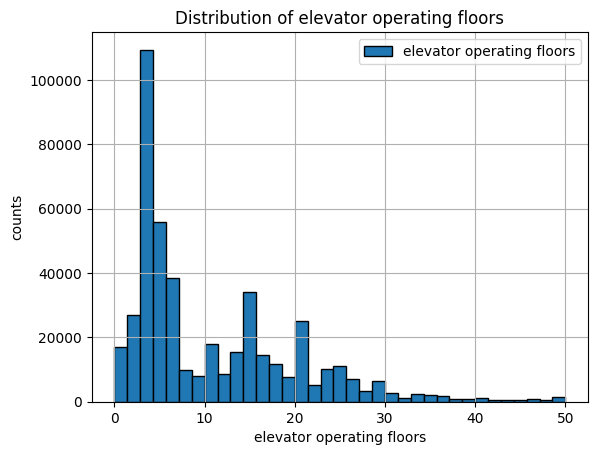

In [7]:
fig, ax = plt.subplots()
newdf["운행지상층수"].hist(ax = ax,bins = np.linspace(0,50,36),edgecolor ='k',label ='elevator operating floors')
ax.set_ylabel("counts")
ax.set_xlabel("elevator operating floors")
ax.set_title("Distribution of elevator operating floors")
ax.legend()